**Lab 7**

Develop a program to demonstrate the working of Linear Regression and Polynomial Regression. Use Boston Housing Dataset for Linear Regression and Auto MPG Dataset (for vehicle fuel efficiency prediction) for Polynomial Regression.

In [ ]:
# Import required packages and dataset
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

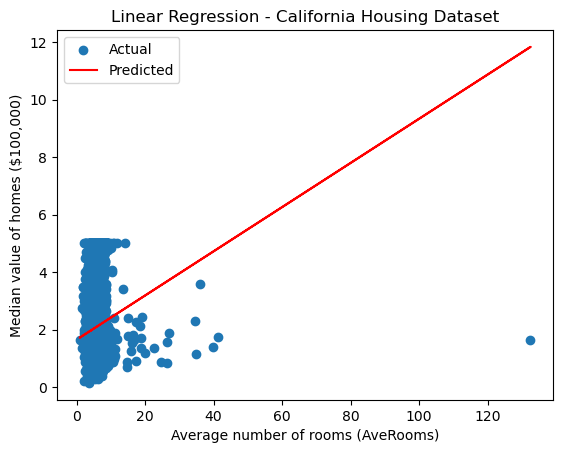

Linear Regression - California Housing Dataset

Mean Squared Error: 1.29233144408073
R^2 Score: 0.01379533753228468


In [11]:
housing = fetch_california_housing(as_frame=True)
X = housing.data[["AveRooms"]]
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_test, y_pred, color="red", label="Predicted")
plt.xlabel("Average number of rooms (AveRooms)")
plt.ylabel("Median value of homes ($100,000)")
plt.title("Linear Regression - California Housing Dataset")
plt.legend()
plt.show()

print("Linear Regression - California Housing Dataset\n")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

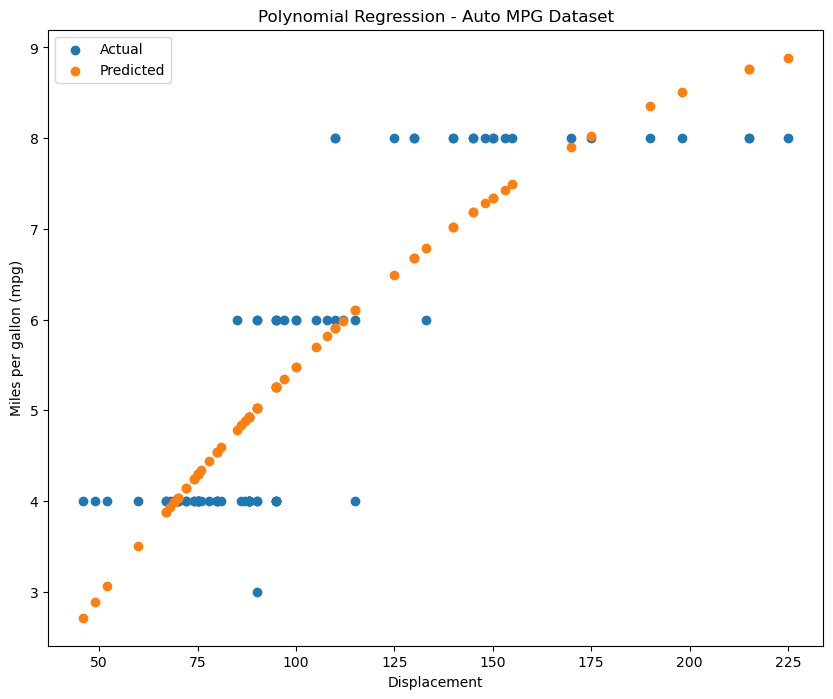

Polynomial Regression - Auto MPG Dataset

Mean Squared Error: 0.7431490557205864
R^2 Score: 0.7505650609469625


In [13]:
column_names = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
]
data = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data",
    sep=r"\s+",
    names=column_names,
    na_values="?",
)
data = data.dropna()

X = data["displacement"].values.reshape(-1, 1)
y = data["mpg"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

poly_model = make_pipeline(
    PolynomialFeatures(degree=2), StandardScaler(), LinearRegression()
)
poly_model.fit(X_train, y_train)

y_pred = poly_model.predict(X_test)

plt.scatter(X_test, y_test, label="Actual")
plt.scatter(X_test, y_pred, label="Predicted")
plt.xlabel("Displacement")
plt.ylabel("Miles per gallon (mpg)")
plt.title("Polynomial Regression - Auto MPG Dataset")
plt.legend()
plt.show()

print("Polynomial Regression - Auto MPG Dataset\n")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))